In [1]:
from google.colab import drive
import sys

In [2]:
drive.mount('/content/drive')
sys.path.append(
"/content/drive/MyDrive/SupportAI"
)

Mounted at /content/drive


#### Загружаем библиотеки и загружаем датасет

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

In [5]:
path = '/content/drive/MyDrive/SupportAI'
filename = f"{path}/data/raw/merged_support_dialogues_humanized_v4.csv"
df = pd.read_csv(filename)

df = df[df['role'] == 'client']
df = df[['dialogue_id', 'turn', 'text', 'role', 'topic', 'intent', 'sentiment',
       'urgency']]
df.to_csv(f"{path}/data/raw/merged_support_dialogues_client_only.csv")

#### Первичный анализ датасета

In [6]:
required_columns = ["turn", "text", "topic", "intent", "sentiment", "urgency"]
missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"В датасете отсутствуют столбцы: {missing}")

In [7]:
df.columns

Index(['dialogue_id', 'turn', 'text', 'role', 'topic', 'intent', 'sentiment',
       'urgency'],
      dtype='object')

In [8]:
df.describe()

,dialogue_id,turn,urgency
count,6344.000000,6344.000000,6344.000000
mean,1751.828026,2.022856,2.860813
std,1016.356207,1.035830,1.240960
min,1.000000,1.000000,1.000000
25%,866.000000,1.000000,2.000000
50%,1761.500000,2.000000,3.000000
75%,2632.250000,3.000000,4.000000
max,3500.000000,5.000000,5.000000


In [9]:
df.head()

,dialogue_id,turn,text,role,topic,intent,sentiment,urgency
0,1,1,Не могли бы вы подсказать: у меня не проходит ...,client,payment,payment_issue,negative,3
2,1,3,"Прошу прощения за беспокойство, карта та же, ч...",client,payment,payment_issue,negative,3
4,2,1,"Привет, деточка, не получается привязать новю ...",client,payment,complaint_issue,negative,4
6,2,3,"Ой, простите за беспокойство, ошибка появляетс...",client,payment,payment_issue,negative,4
8,2,5,"Вот веьд незадача... спасибо большое, буду жда...",client,payment,gratitude,positive,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6344 entries, 0 to 12140
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   dialogue_id  6344 non-null   int64 
 1   turn         6344 non-null   int64 
 2   text         6344 non-null   object
 3   role         6344 non-null   object
 4   topic        6344 non-null   object
 5   intent       6344 non-null   object
 6   sentiment    6344 non-null   object
 7   urgency      6344 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 446.1+ KB


In [11]:
df.isnull().sum()

,0
dialogue_id,0
turn,0
text,0
role,0
topic,0
intent,0
sentiment,0
urgency,0


In [13]:
df.shape[0]

6344

In [12]:
df.duplicated(['text']).sum()

np.int64(560)

In [14]:
df.drop_duplicates(['text'], keep='first')

,dialogue_id,turn,text,role,topic,intent,sentiment,urgency
0,1,1,Не могли бы вы подсказать: у меня не проходит ...,client,payment,payment_issue,negative,3
2,1,3,"Прошу прощения за беспокойство, карта та же, ч...",client,payment,payment_issue,negative,3
4,2,1,"Привет, деточка, не получается привязать новю ...",client,payment,complaint_issue,negative,4
6,2,3,"Ой, простите за беспокойство, ошибка появляетс...",client,payment,payment_issue,negative,4
8,2,5,"Вот веьд незадача... спасибо большое, буду жда...",client,payment,gratitude,positive,1
...,...,...,...,...,...,...,...,...
12133,3498,3,"Дееточка, поняла, спасибо огромное...",client,return,gratitude,positive,1
12134,3499,1,"Товар пришёл с браком, хочу вернуть деньги!",client,return,return_issue,negative,4
12136,3499,3,"Веьщ ноавя, бирки на месте, пакет тоже сохрани...",client,return,response,neutral,2
12138,3500,1,"Передумал покупать, хоочу вернуть закза пока н...",client,return,return_issue,negative,3


In [15]:
df.duplicated(['text']).sum()

np.int64(560)

In [16]:
df.sample(10, random_state=42)

,dialogue_id,turn,text,role,topic,intent,sentiment,urgency
1405,395,3,Код ошибки такой: ERR_CARD_LIMIT. Могу описать...,client,payment,response,neutral,1
9097,2632,1,"Здрасте, ну вот, курьер до сих пор не прриехал...",client,delivery,delivery_issue,neutral,3
9585,2774,1,"Нужно перенести заказ на другой день, планы по...",client,delivery,delivery_issue,neutral,4
8179,2365,1,"Внезапно (нет), подписка продлилась сама, хотя...",client,subscription,subscription_issue,negative,5
424,112,4,"Хорошо, договорились.",client,payment,acknowledgment,neutral,1
5153,1483,2,Добрый день. форма обратной связи не отправляе...,client,technical_issue,response,neutral,3
4323,1237,3,"Подскажите, пожалуйста: телефон Honor 90, прил...",client,technical_issue,response,neutral,2
10290,2978,1,"Заказ показывает саттус ""доставлен"", но по фат...",client,delivery,delivery_issue,negative,4
3201,909,4,"Сын подсказал написать вам: понял, ждём...",client,complaint,acknowledgment,neutral,4
6070,1755,3,"Извините, ребёнок плачет, отввлеклась, номер т...",client,account_access,response,neutral,1


In [17]:
df['topic'].value_counts()

,count
topic,
return,924
payment,920
complaint,913
subscription,910
delivery,902
account_access,901
technical_issue,874


#### Проверка распределения каждого класса столбцов

In [18]:
def hist_plot(df:pd.DataFrame, feature:str, color='blue', rotation=False, class_distribution=True):
    plt.figure(figsize=(11, 7))
    display(df[feature].describe())
    counts = df[feature].value_counts()
    if class_distribution:
        display(df[feature].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
    plt.bar(counts.index, counts.values, color=color, edgecolor='black')
    plt.title(f'Распределение признака {feature}', fontsize=16)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Количество", fontsize=12)
    if rotation:
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

,role
count,6344
unique,1
top,client
freq,6344


,proportion
role,
client,100.0%


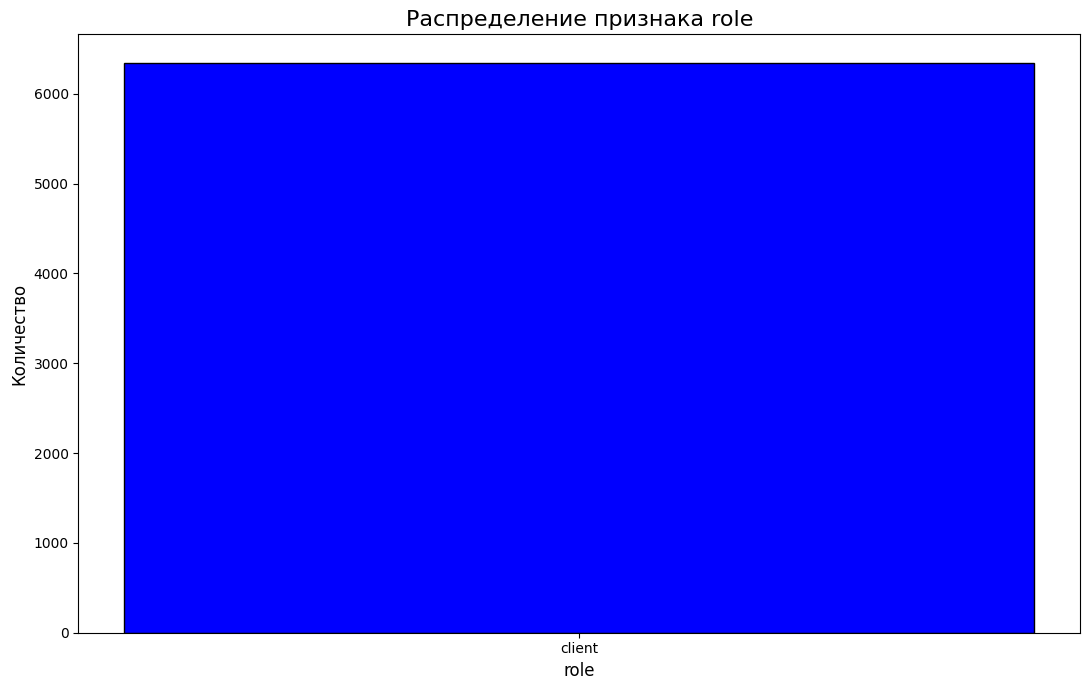

In [19]:
hist_plot(df, 'role')

,topic
count,6344
unique,7
top,return
freq,924


,proportion
topic,
return,14.56%
payment,14.5%
complaint,14.39%
subscription,14.34%
delivery,14.22%
account_access,14.2%
technical_issue,13.78%


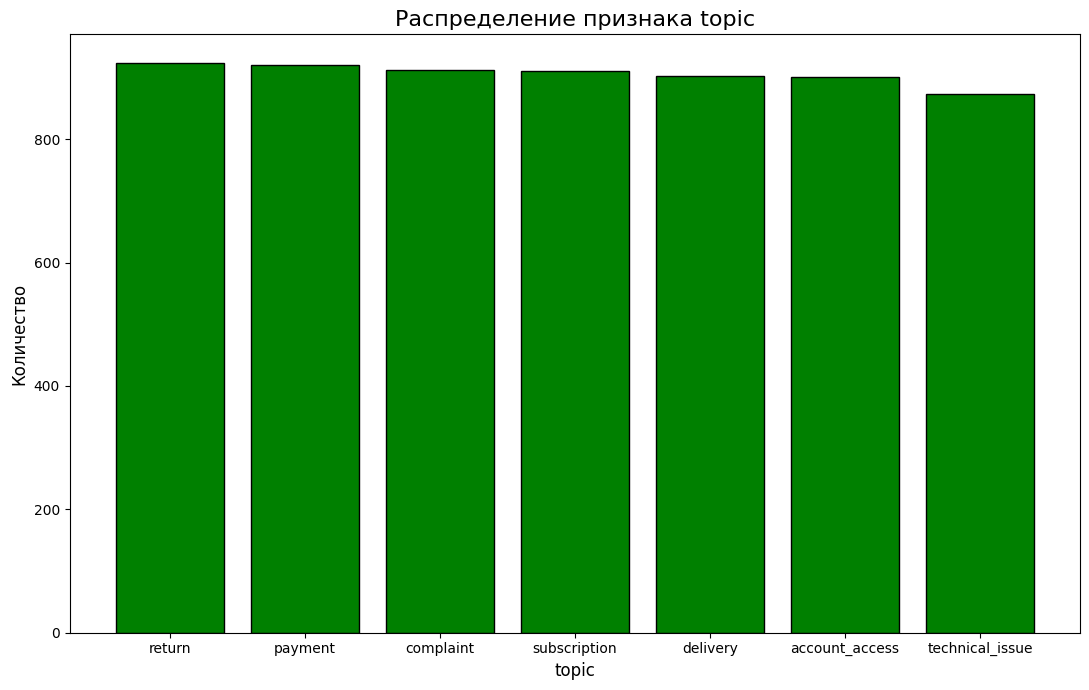

In [20]:
hist_plot(df, 'topic', color='green')

,intent
count,6344
unique,11
top,response
freq,2448


,proportion
intent,
response,38.59%
gratitude,8.56%
complaint_issue,7.11%
account_access_issue,6.95%
technical_issue_issue,6.87%
subscription_issue,6.86%
delivery_issue,6.83%
return_issue,6.62%
payment_issue,5.6%


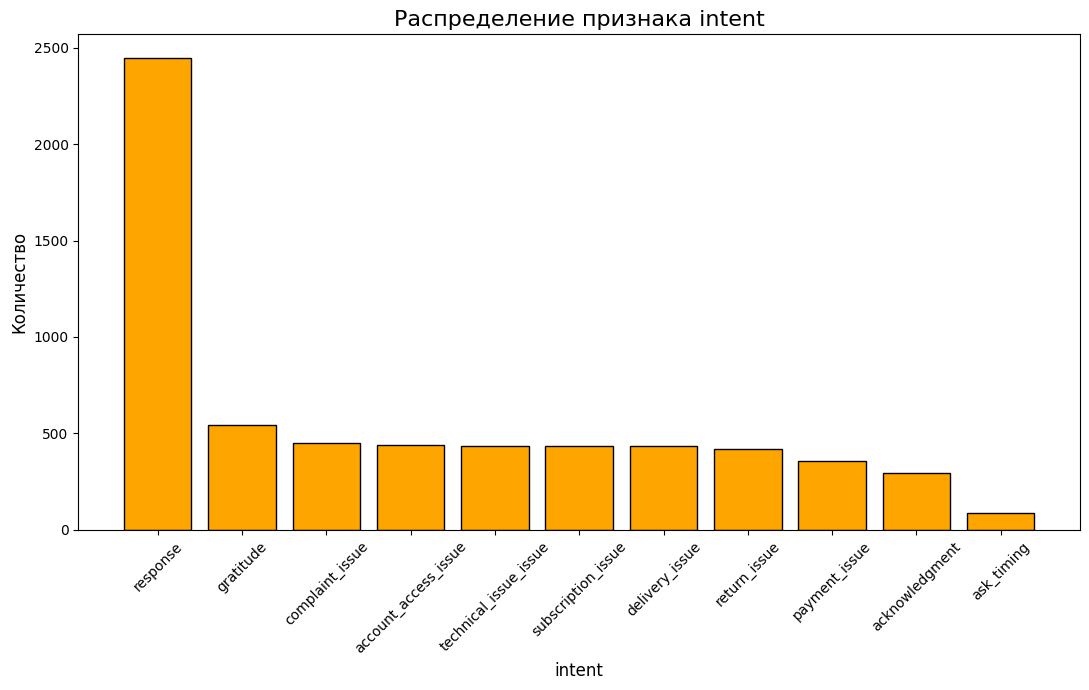

In [21]:
hist_plot(df, 'intent', color='orange', rotation=True)

,sentiment
count,6344
unique,3
top,neutral
freq,3873


,proportion
sentiment,
neutral,61.05%
negative,29.68%
positive,9.27%


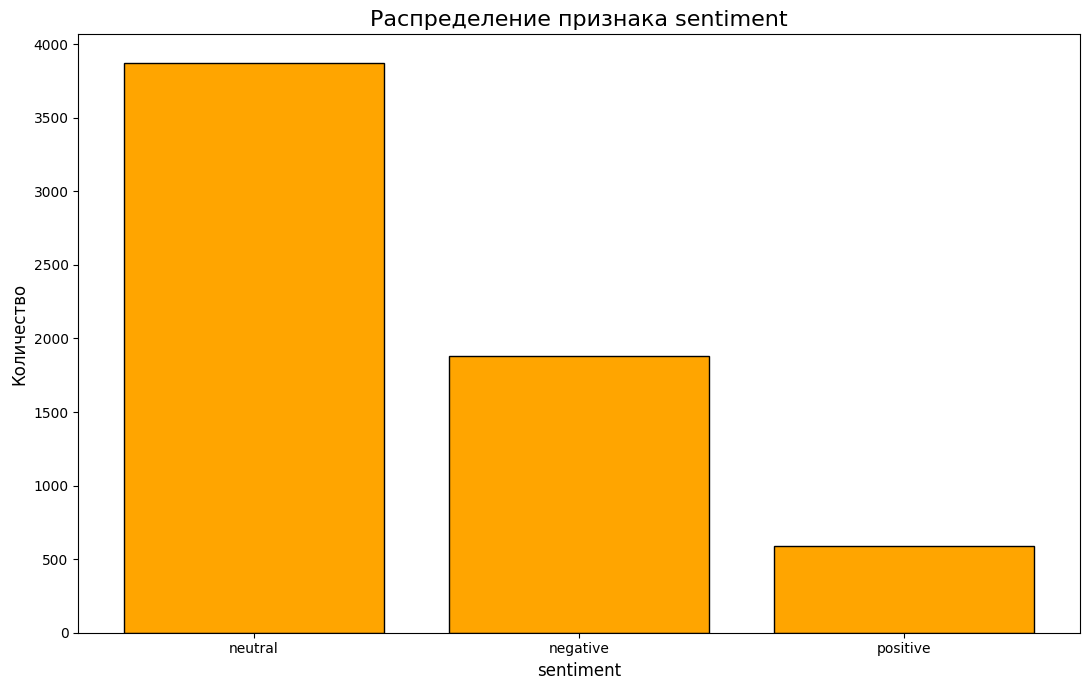

In [22]:
hist_plot(df, 'sentiment', color='orange')

,urgency
count,6344.000000
mean,2.860813
std,1.240960
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


,proportion
urgency,
3,26.18%
2,23.53%
4,22.92%
1,17.01%
5,10.36%


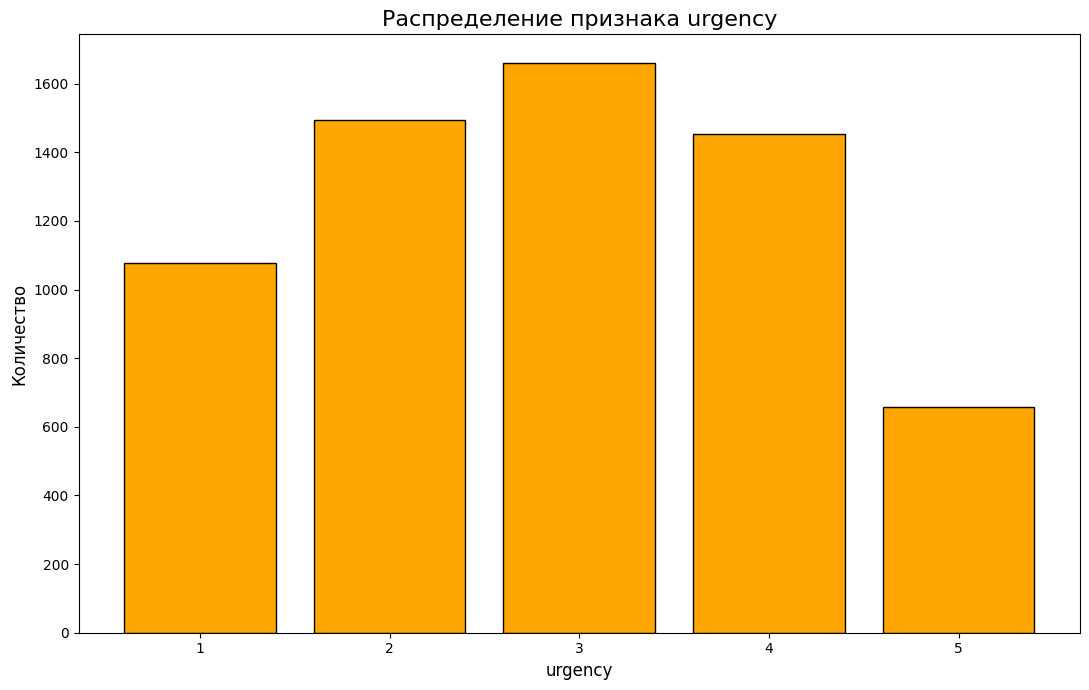

In [23]:
hist_plot(df, 'urgency', color='orange')

In [24]:
df['length']=df['text'].str.len()
df['length'].describe()

,length
count,6344.000000
mean,77.290511
std,25.658601
min,12.000000
25%,59.000000
50%,76.000000
75%,94.000000
max,163.000000


In [25]:
shortest_message = df.loc[df['length'] == df['length'].min()]
shortest_message

,dialogue_id,turn,text,role,topic,intent,sentiment,urgency,length
1634,461,4,"Понял, ждём.",client,payment,acknowledgment,neutral,3,12
2198,622,4,"Понял, ждём.",client,complaint,acknowledgment,neutral,4,12
6104,1765,4,"Понял, ждём!",client,account_access,acknowledgment,neutral,3,12
8772,2536,4,"Понял, ждём!",client,delivery,acknowledgment,neutral,3,12
9927,2872,4,"Понял, ждём.",client,delivery,acknowledgment,neutral,3,12


In [26]:
largest_message = df.loc[df['length'] == df['length'].max()]
largest_message

,dialogue_id,turn,text,role,topic,intent,sentiment,urgency,length
10824,3130,1,"Здравствуйте, не хочу показаться навязчивым, н...",client,return,return_issue,neutral,2,163


,length
count,6344.000000
mean,77.290511
std,25.658601
min,12.000000
25%,59.000000
50%,76.000000
75%,94.000000
max,163.000000


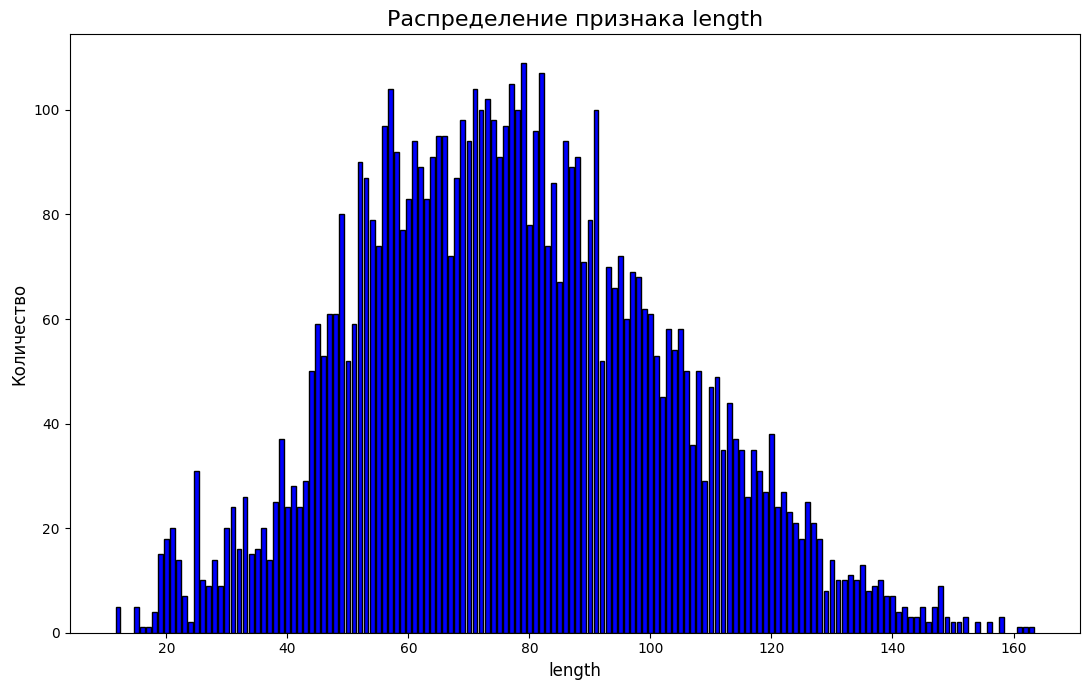

In [27]:
hist_plot(df, 'length', class_distribution=False)

,length_words
count,6344.000000
mean,11.767339
std,4.081052
min,2.000000
25%,9.000000
50%,12.000000
75%,14.000000
max,27.000000


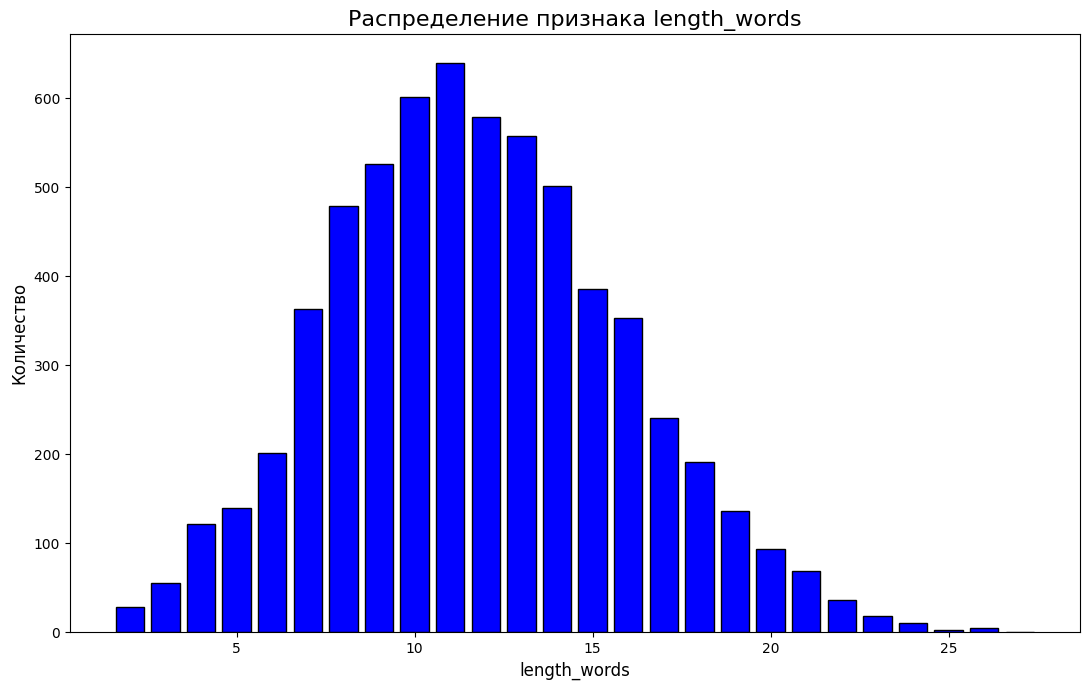

In [28]:
df["length_words"] = df["text"].str.split().str.len()
hist_plot(df, 'length_words', class_distribution=False)

In [29]:
tokenizer = AutoTokenizer.from_pretrained(
    "DeepPavlov/rubert-base-cased"
)

df["tokens"] = df["text"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

,tokens
count,6344.000000
mean,18.581021
std,6.512656
min,4.000000
25%,14.000000
50%,18.000000
75%,23.000000
max,45.000000


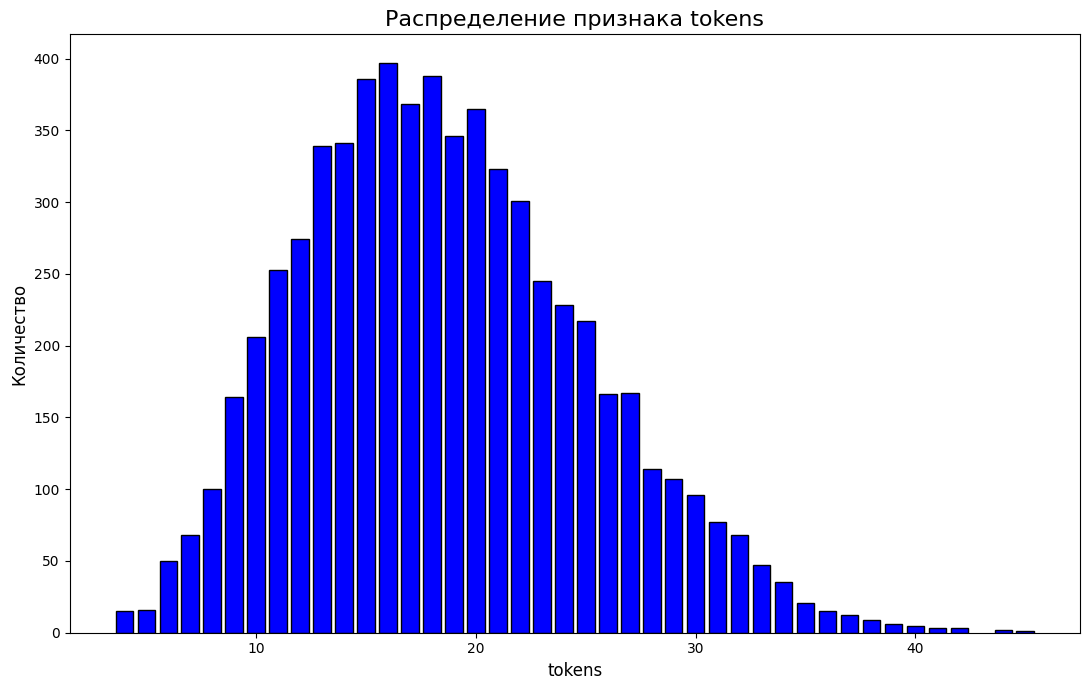

In [30]:
hist_plot(df, 'tokens', class_distribution=False)

### Отчет по первичной обработке данных

In [31]:
print(f'Количество столбцов в датасете: {df.shape[1]}')
print(f'Столбцы в датасете: {list(df.columns)}')
print(f'Количество строк в датасете: {df.shape[0]}')
print(f'Количество дубликатов текста обращения в датасете: {df.duplicated(["text"]).sum()}')
print(f'Количество пропусков: {df.isnull().sum().sum()}')
print(f'Максимальная длина сообщения: {df["length"].max()}')
print(f'Минимальная длина сообщения: {df["length"].min()}')
print(f'Максимум токенов: {df["tokens"].max()}')
print(f'Среднее число токенов: {df["tokens"].mean()}')

Количество столбцов в датасете: 11
Столбцы в датасете: ['dialogue_id', 'turn', 'text', 'role', 'topic', 'intent', 'sentiment', 'urgency', 'length', 'length_words', 'tokens']
Количество строк в датасете: 6344
Количество дубликатов текста обращения в датасете: 560
Количество пропусков: 0
Максимальная длина сообщения: 163
Минимальная длина сообщения: 12
Максимум токенов: 45
Среднее число токенов: 18.581021437578816
